<a href="https://colab.research.google.com/github/marsya505/DataMining/blob/main/Week6-Pumkin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving new-york_9-24-2016_9-30-2017.csv to new-york_9-24-2016_9-30-2017 (1).csv
R-squared (R2): -0.26
MSE: 32.93


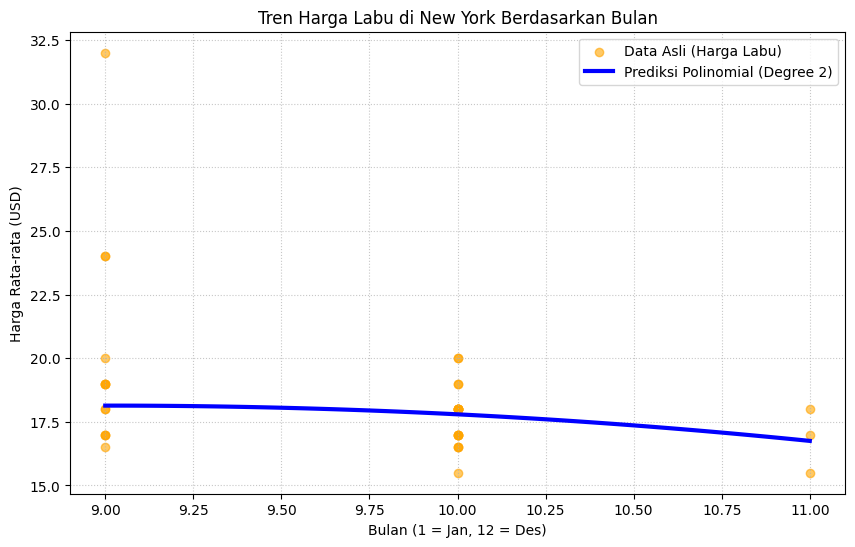

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

from google.colab import files

uploaded = files.upload()
data = pd.read_csv("new-york_9-24-2016_9-30-2017.csv")

data = data[data['Package'].str.contains('bushel', case=True, regex=True)].copy()

data['Price'] = (data['Low Price'] + data['High Price']) / 2

data['Date'] = pd.to_datetime(data['Date'])
data['Month'] = data['Date'].dt.month

X = data[['Month']].values
y = data['Price'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

model = LinearRegression()
model.fit(X_poly_train, y_train)

y_pred = model.predict(X_poly_test)
print(f"R-squared (R2): {r2_score(y_test, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")

X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_range_pred = model.predict(poly.transform(X_range))

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='orange', alpha=0.6, label='Data Asli (Harga Labu)')
plt.plot(X_range, y_range_pred, color='blue', linewidth=3, label='Prediksi Polinomial (Degree 2)')

plt.title('Tren Harga Labu di New York Berdasarkan Bulan')
plt.xlabel('Bulan (1 = Jan, 12 = Des)')
plt.ylabel('Harga Rata-rata (USD)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()